In [1]:
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from tqdm.autonotebook import tqdm

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.layers import (
    Flatten,
    Dense,
    BatchNormalization,
    Activation,
    Dropout,
    Lambda,
    Input,
    GlobalAveragePooling2D,
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img



/tmp/ipykernel_55/3063464627.py:9: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
2026-05-06 08:03:10.165275: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778054590.179216      55 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778054590.183479      55 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-06 08:03:10.202498: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instruct

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
labels = pd.read_csv("/kaggle/input/dog-breed-identification/labels.csv")
labels.head()



,id,breed
0,8406d837b2d7fac1c3cd621abb4c4f9e,west_highland_white_terrier
1,e270622b5ffec8294d7e7628c4ff6c1e,brittany_spaniel
2,41295c36303043fc587e791b14ef2272,basset
3,b63b0200ddbb97df81972b26574959ab,boxer
4,2c64e362c9aa29450082291264dcba29,flat-coated_retriever


In [3]:
classes = sorted(list(set(labels["breed"])))
n_classes = len(classes)
print("Total unique breed {}".format(n_classes))

class_to_num = dict(zip(classes, range(n_classes)))



Total unique breed 120


In [4]:
input_shape = (331, 331, 3)


def images_to_array(directory, label_dataframe, target_size=input_shape):

    image_labels = label_dataframe["breed"]
    images = np.zeros(
        [len(label_dataframe), target_size[0], target_size[1], target_size[2]],
        dtype=np.uint8,
    )
    y = np.zeros([len(label_dataframe), 1], dtype=np.uint8)

    for ix, image_name in enumerate(tqdm(label_dataframe["id"].values)):
        img_path = os.path.join(directory, image_name + ".jpg")
        img = load_img(img_path, target_size=target_size)
        images[ix] = img
        dog_breed = image_labels.iloc[ix]
        y[ix] = class_to_num[dog_breed]

    y = to_categorical(y, num_classes=n_classes)

    return images, y




In [5]:
import time

t = time.time()

X, y = images_to_array("/kaggle/input/dog-breed-identification/train", labels[:])

print("runtime in seconds: {}".format(time.time() - t))



  0%|          | 0/9199 [00:00<?, ?it/s]

runtime in seconds: 12.30347990989685


In [6]:
# ReduceLROnPlateau must monitor the new metric name 'val_accuracy'
lrr = ReduceLROnPlateau(
    monitor="val_accuracy", factor=0.01, patience=3, min_lr=1e-5, verbose=1
)

EarlyStop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)



In [7]:
batch_size = 128
epochs = 100
learn_rate = 0.001
sgd = SGD(learning_rate=learn_rate, momentum=0.9, nesterov=False)
adam = Adam(learning_rate=learn_rate)



2026-05-06 08:03:29.013417: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1778054609.014503      55 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:c6:00.0, compute capability: 8.6


In [8]:
img_size = (331, 331, 3)


def get_features(model_name, model_preprocessor, input_size, data):
    input_layer = Input(shape=input_size)
    preprocessor = Lambda(model_preprocessor)(input_layer)
    base_model = model_name(
        weights="imagenet", include_top=False, input_shape=input_size
    )(preprocessor)
    avg = GlobalAveragePooling2D()(base_model)
    feature_extractor = Model(inputs=input_layer, outputs=avg)
    feature_maps = feature_extractor.predict(data, verbose=1)
    print("Feature maps shape: ", feature_maps.shape)
    return feature_maps




In [9]:
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input

inception_preprocessor = preprocess_input
inception_features = get_features(InceptionV3, inception_preprocessor, img_size, X)

print("Inception feature maps shape", inception_features.shape)



87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


I0000 00:00:1778054618.567050     107 service.cc:148] XLA service 0x7fd6d00d6750 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778054618.567082     107 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-05-06 08:03:38.631077: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778054619.119369     107 cuda_dnn.cc:529] Loaded cuDNN version 90300


  7/288 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step

I0000 00:00:1778054624.056959     107 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


288/288 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step
Feature maps shape:  (9199, 2048)
Inception feature maps shape (9199, 2048)


In [10]:
del X  # free RAM
gc.collect()



69014

In [11]:
model = Sequential()
model.add(Dropout(0.7, input_shape=(inception_features.shape[1],)))
model.add(Dense(n_classes, activation="softmax"))

model.compile(optimizer=adam, loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(
    inception_features,
    y,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=[lrr, EarlyStop],
)



Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/regularization/dropout.py:42: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2026-05-06 08:03:59.645329: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_514', 108 bytes spill stores, 108 bytes spill loads



43/58 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1187 - loss: 4.3939 

2026-05-06 08:04:00.947060: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_514', 76 bytes spill stores, 76 bytes spill loads

2026-05-06 08:04:01.169257: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_514', 4 bytes spill stores, 4 bytes spill loads

2026-05-06 08:04:01.203156: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_514', 4 bytes spill stores, 4 bytes spill loads

2026-05-06 08:04:01.573303: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_514', 96 bytes spill stores, 96 bytes spill loads

2026-05-06 08:04:01.608162: I external/local_xla/xla/stream_executor

58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.1828 - loss: 4.1214 - val_accuracy: 0.8538 - val_loss: 1.4177 - learning_rate: 0.0010
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8114 - loss: 1.2123 - val_accuracy: 0.8880 - val_loss: 0.6140 - learning_rate: 0.0010
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8773 - loss: 0.6016 - val_accuracy: 0.8940 - val_loss: 0.4470 - learning_rate: 0.0010
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8985 - loss: 0.4315 - val_accuracy: 0.8957 - val_loss: 0.3951 - learning_rate: 0.0010
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9038 - loss: 0.3702 - val_accuracy: 0.8962 - val_loss: 0.3592 - learning_rate: 0.0010
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9145 - loss: 0.3142 - val_accuracy: 0.8995 - val_loss: 0.3416 - learning_rate: 0.0010
Epoch 7/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9253 - loss: 0.2820 - val_accuracy: 0.90

In [12]:
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │       245,880 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 737,642 (2.81 MB)

 Trainable params: 245,880 (960.47 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 491,762 (1.88 MB)

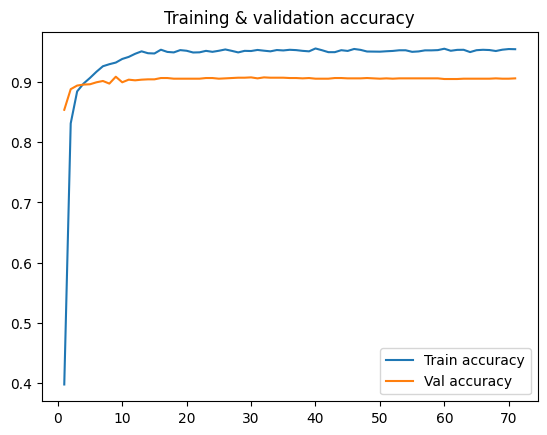

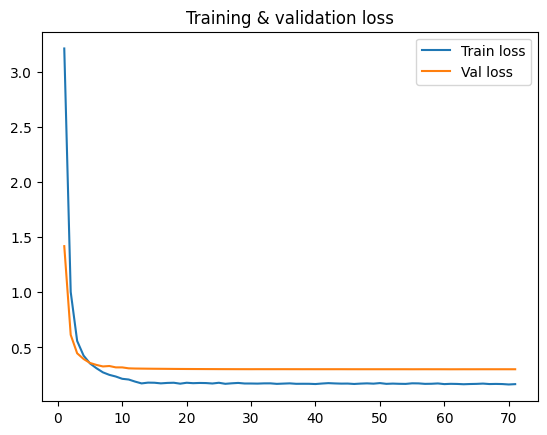

In [13]:
# Plot training curves
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(1, len(acc) + 1)

plt.figure()
plt.plot(epochs_range, acc, label="Train accuracy")
plt.plot(epochs_range, val_acc, label="Val accuracy")
plt.title("Training & validation accuracy")
plt.legend()

plt.figure()
plt.plot(epochs_range, loss, label="Train loss")
plt.plot(epochs_range, val_loss, label="Val loss")
plt.title("Training & validation loss")
plt.legend()
plt.show()




In [14]:
def images_to_array_test(test_path, img_size=(331, 331, 3)):
    # collect only image files (skip directories)
    all_entries = os.listdir(test_path)
    file_names = [f for f in all_entries if f.lower().endswith(".jpg")]
    data_size = len(file_names)
    images = np.zeros([data_size, img_size[0], img_size[1], 3], dtype=np.uint8)

    for ix, fname in enumerate(tqdm(file_names)):
        img_path = os.path.join(test_path, fname)
        img = load_img(img_path, target_size=img_size)
        images[ix] = img
        del img
    print("Output Data Size: ", images.shape)
    return images, file_names


test_data, test_filenames = images_to_array_test(
    "/kaggle/input/dog-breed-identification/test/", img_size
)




  0%|          | 0/1023 [00:00<?, ?it/s]

Output Data Size:  (1023, 331, 331, 3)


In [15]:
def extract_features(data):
    feats = get_features(InceptionV3, inception_preprocessor, img_size, data)
    print("Inception feature maps shape", feats.shape)
    return feats


test_features = extract_features(test_data)



32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 237ms/step
Feature maps shape:  (1023, 2048)
Inception feature maps shape (1023, 2048)


In [16]:
del test_data
gc.collect()



76556

In [17]:
pred = model.predict(test_features)



32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [18]:
preds_df = pd.DataFrame(columns=["id"] + list(classes))

# derive ids from filenames (remove .jpg)
preds_df["id"] = [os.path.splitext(fname)[0] for fname in test_filenames]



In [19]:
preds_df.loc[:, list(classes)] = pred
preds_df.to_csv("submission.csv", index=False)

print("Submission file saved as submission.csv")

Submission file saved as submission.csv
